## Imports

In [1]:
import pybinding as pb
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp2d
from pybinding.repository import graphene

## Data load (Onsite_energy) _fig1

2.8988422506844005
2.164307 0.3450340000000003
4.987318999999999 1.003737


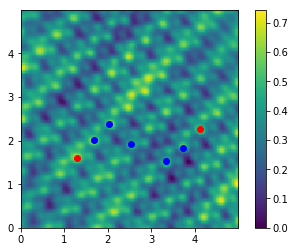

In [12]:
data = np.loadtxt("20790.txt") 
zdata = np.loadtxt("20790z.txt")
zdata = np.flip(zdata, 1)
zdata = zdata*10**10
xdata = data[:,0]
xdata = xdata[0:160] 
ydata = xdata

plt.imshow(zdata, vmin=zdata.min(), vmax=zdata.max(), origin='lower',
           extent=[xdata.min(), xdata.max(), ydata.min(), ydata.max()]) #imshow
plt.colorbar()

plt.scatter(1.286038,1.599706, c='r', marker='o') #6.82313E-011
plt.scatter(1.693807,2.007475, c='b', marker='o')
plt.scatter(2.038842,2.383876, c='b', marker='o')
plt.scatter(2.540710,1.913374, c='b', marker='o')
plt.scatter(3.324880,1.536973, c='b', marker='o')
plt.scatter(3.732648,1.819274, c='b', marker='o')
plt.scatter(4.109050,2.258409, c='r', marker='o') #6.14744E-011

dx=4.109050-1.286038 
dy=2.258409-1.599706
print(np.sqrt(dx**2+dy**2))

theta = np.arctan(dy/dx)*180/np.pi

a1=[1.693807-1.286038, 2.007475-1.599706] #To find other atoms easily
a2=[3.324880-2.540710, 1.536973-1.913374] 
a3=[2.540710-2.038842, 1.913374-2.383876]

#plt.scatter(1.286038+a2[0]-a1[0]+a3[0],1.599706+a2[1]-a1[1]+a3[1], c='r', marker='o')
#plt.scatter(4.109050+a2[0]-a1[0]+a3[0],2.258409+a2[1]-a1[1]+a3[1], c='r', marker='o')

print(1.286038+a2[0]-a1[0]+a3[0],1.599706+a2[1]-a1[1]+a3[1])
print(4.109050+a2[0]-a1[0]+a3[0],2.258409+a2[1]-a1[1]+a3[1])



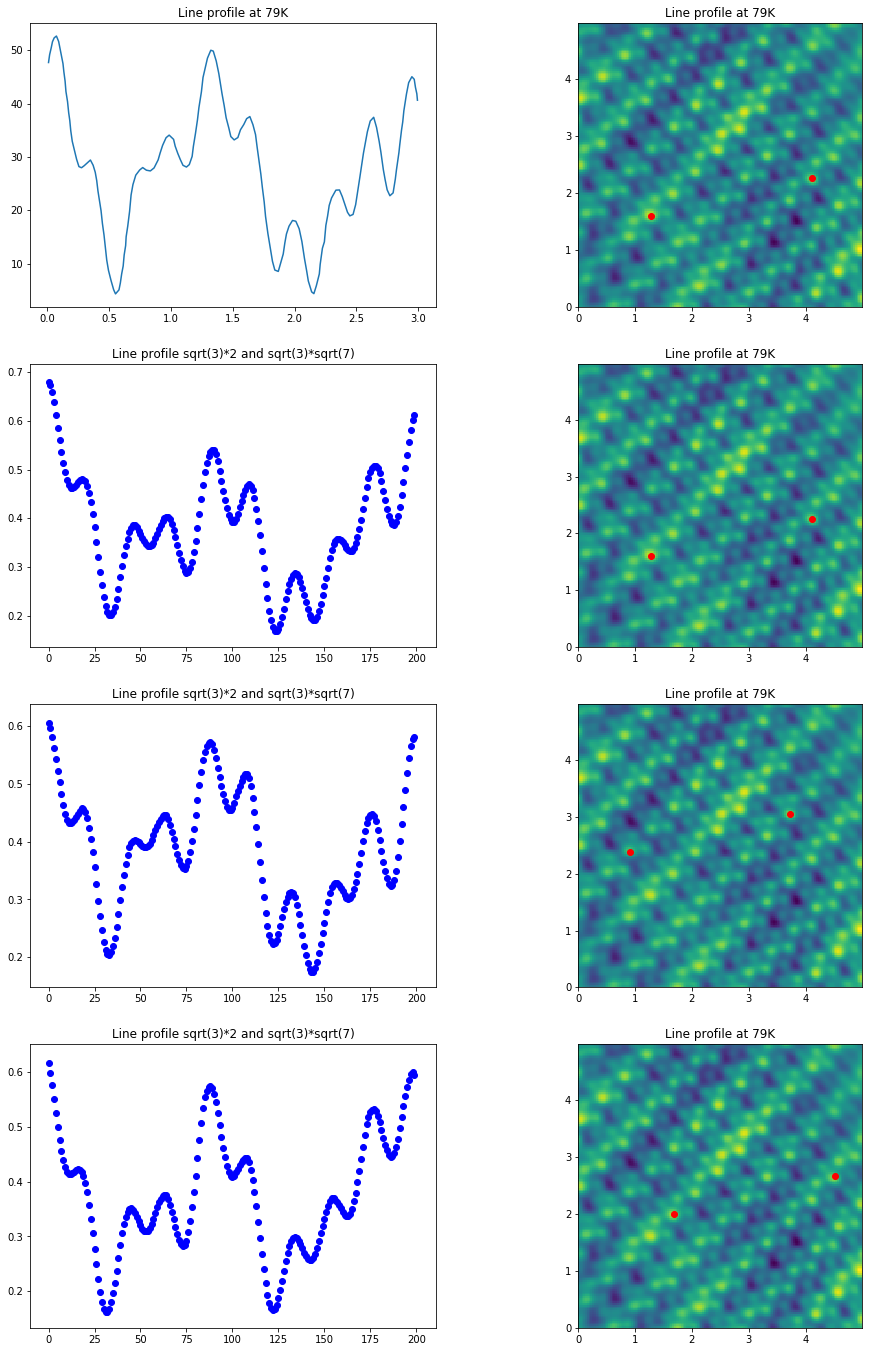

In [13]:
g79K = np.loadtxt("g79K_blue.txt")
xdata_g79 = g79K[:,0] 
ydata_g79 = g79K[:,1] 

f=interp2d(xdata, ydata, zdata, kind='cubic') #Using interp2d

#fig1
plt.figure(figsize=(16,24))
plt.subplot(421, title = "Line profile at 79K")
plt.plot(xdata_g79,ydata_g79)
#fig2
plt.subplot(422, title = "Line profile at 79K")
plt.imshow(zdata, vmin=zdata.min(), vmax=zdata.max(), origin='lower',
           extent=[xdata.min(), xdata.max(), ydata.min(), ydata.max()])
plt.scatter(1.286038,1.599706, c='r') 
plt.scatter(4.109050,2.258409, c='r')
#fig3
plt.subplot(423, title = "Line profile sqrt(3)*2 and sqrt(3)*sqrt(7)")
x_red=np.arange(1.286038,4.109050, step=dx/200)
y_red=np.arange(1.599706,2.258409, step=dy/200)
for i in range(200):
    plt.scatter(i, f(x_red[i],y_red[i]), c='b') 
#fig4
plt.subplot(424, title = "Line profile at 79K")
plt.imshow(zdata, vmin=zdata.min(), vmax=zdata.max(), origin='lower',
           extent=[xdata.min(), xdata.max(), ydata.min(), ydata.max()])
plt.scatter(1.286038,1.599706, c='r') 
plt.scatter(4.109050,2.258409, c='r')
#fig5
plt.subplot(425, title = "Line profile sqrt(3)*2 and sqrt(3)*sqrt(7)")
x_red2=np.arange(1.286038-a2[0]+a1[0],4.109050-a2[1]+a1[1], step=dx/200)
y_red2=np.arange(1.599706-a2[0]+a1[0],2.258409-a2[1]+a1[1], step=dy/200)
for i in range(200):
    plt.scatter(i, f(x_red2[i],y_red2[i]), c='b') 
#fig6
plt.subplot(426, title = "Line profile at 79K")
plt.imshow(zdata, vmin=zdata.min(), vmax=zdata.max(), origin='lower',
           extent=[xdata.min(), xdata.max(), ydata.min(), ydata.max()])
plt.scatter(1.286038-a2[0]+a1[0],1.599706-a2[1]+a1[1], c='r') 
plt.scatter(4.109050-a2[0]+a1[0],2.258409-a2[1]+a1[1], c='r')
#fig7
plt.subplot(427, title = "Line profile sqrt(3)*2 and sqrt(3)*sqrt(7)")
x_red3=np.arange(1.286038+a1[0],4.109050+a1[1], step=dx/200)
y_red3=np.arange(1.599706+a1[0],2.258409+a1[1], step=dy/200)
for i in range(200):
    plt.scatter(i, f(x_red3[i],y_red3[i]), c='b') 
#fig8
plt.subplot(428, title = "Line profile at 79K")
plt.imshow(zdata, vmin=zdata.min(), vmax=zdata.max(), origin='lower',
           extent=[xdata.min(), xdata.max(), ydata.min(), ydata.max()])
plt.scatter(1.286038+a1[0],1.599706+a1[1], c='r') 
plt.scatter(4.109050+a1[0],2.258409+a1[1], c='r')

## ML graphene lattice

In [14]:
def monolayer_graphene():
    a = 0.246   # [nm] unit cell length
    a_cc = a/np.sqrt(3)  # [nm] carbon-carbon distance
    t = -2.8      # [eV] nearest neighbour hopping

    lat = pb.Lattice(a1=[a, 0],
                     a2=[a/2, a/2 * np.sqrt(3)])
    lat.add_sublattices(('A', [0, -a_cc/2]),
                        ('B', [0,  a_cc/2]))
    lat.add_hoppings(
        # inside the main cell
        ([0,  0], 'A', 'B', t),
        # between neighboring cells
        ([1, -1], 'A', 'B', t),
        ([0, -1], 'A', 'B', t)
    )
    return lat

## CellSize=12

3.9049041


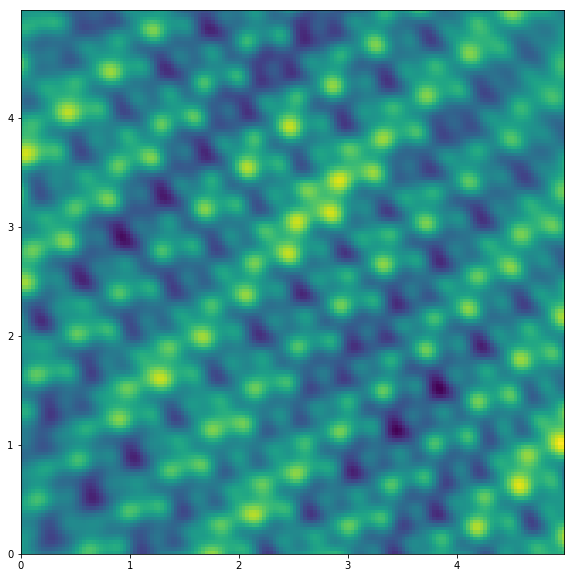

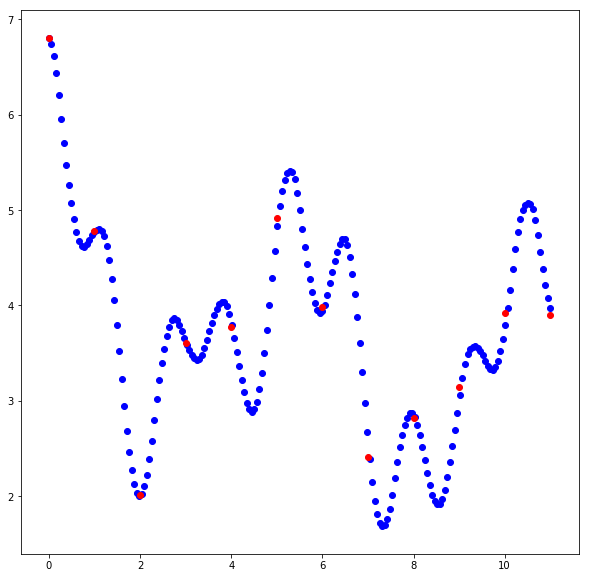

In [76]:
cellSize = 12

zdata = np.loadtxt("20790z.txt")
zdata = np.flip(zdata, 1)
zdata = zdata*2.5*10**10*4
zav = np.average(zdata)
f=interp2d(xdata, ydata, zdata, kind='cubic') #Using interp2d

target=[-2.2140002, -1.2072394]
target2=[0.49199986, -1.2072394]
VSe1=[1.286038,1.599706]
VSe2=[4.109050,2.258409]
            
a=VSe1[0]-np.dot(rot,target)[0]
b=VSe1[1]-np.dot(rot,target)[1]
xdata_temp=np.zeros(len(xdata))
ydata_temp=np.zeros(len(xdata))
def wavy(theta,a,b):
    @pb.onsite_energy_modifier
    def potential(x, y):
        #print(x[11],y[0])
        pot=np.zeros(len(x))
        for i in range(len(x)):
            xdata_temp[i]=np.dot(rot,[x[i],y[i]])[0]+a
            ydata_temp[i]=np.dot(rot,[x[i],y[i]])[1]+b
            pot[i]=f(xdata_temp[i],ydata_temp[i])
            #plt.scatter(xdata_temp[i],ydata_temp[i], c='r')
        #print(pot[1], pot[2],pot[3])
        return pot
    return potential

model = pb.Model(
    monolayer_graphene(),
    pb.primitive(a1=cellSize, a2=cellSize),
    pb.translational_symmetry(a1=cellSize*0.246, a2=cellSize*0.246),
    wavy(theta,a,b)
)

plt.figure(figsize=(10,10))
#model.onsite_map.plot(site_radius=0.04)
print(model.onsite_map.data[0])
plt.imshow(zdata, vmin=zdata.min(), vmax=zdata.max(), origin='lower',
           extent=[xdata.min(), xdata.max(), ydata.min(), ydata.max()])
#plt.xlim(-5,5)
#plt.ylim(-5,5)
plt.figure(figsize=(10,10))

x_ori=np.arange(VSe1[0],VSe2[0], step=dx/201)
y_ori=np.arange(VSe1[1],VSe2[1], step=dy/201)
x_red=np.arange(np.dot(rot, target)[0]+a, np.dot(rot, target2)[0]+a, step=2.6352143306788003/201)
y_red=np.arange(np.dot(rot, target)[1]+b, np.dot(rot, target2)[1]+b, step=0.6148835305202804/201)

for i in range(201):
    #plt.scatter(i/200*11, f(x_ori[i],y_ori[i]), c='r') 
    plt.scatter(i/200*11, f(x_red[i],y_red[i]), c='b') 
plt.scatter(range(12), model.onsite_map.data[144:144+12], c='r')

In [90]:
#np.sum(zdata[0:143]) - np.sum(zdata[144:288])
#
#print((model.hamiltonian.todense))
#print(len(zdata[0:144]))
#print(len(zdata[144:288]))

A = sum(model.onsite_map.data[0:144])
B = sum(model.onsite_map.data[144:288])
print(A,B)

massTerm = A-B
print(massTerm)


518.2195558547974 520.6346119642258
-2.4150561094284058


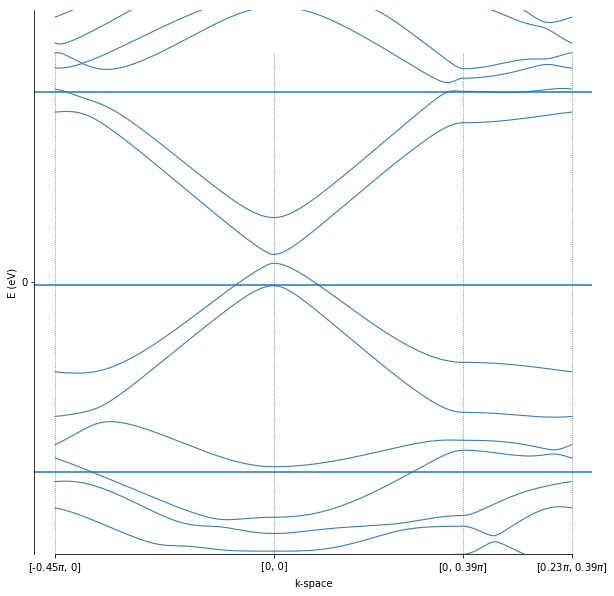

In [59]:
solver = pb.solver.lapack(model)
a_cc = graphene.a_cc
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 0]
M = [0, 2*np.pi / (3*a_cc)/cellSize]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 2*np.pi / (3*a_cc)/cellSize]
bands = solver.calc_bands(K1, Gamma, M, K2,step=0.01)
plt.figure(figsize=(10,10))
bands.plot()
plt.ylim(-1.0,1.0)
plt.axhline(-0.01)
plt.axhline(0.7)
plt.axhline(-0.7)

-0.032567024


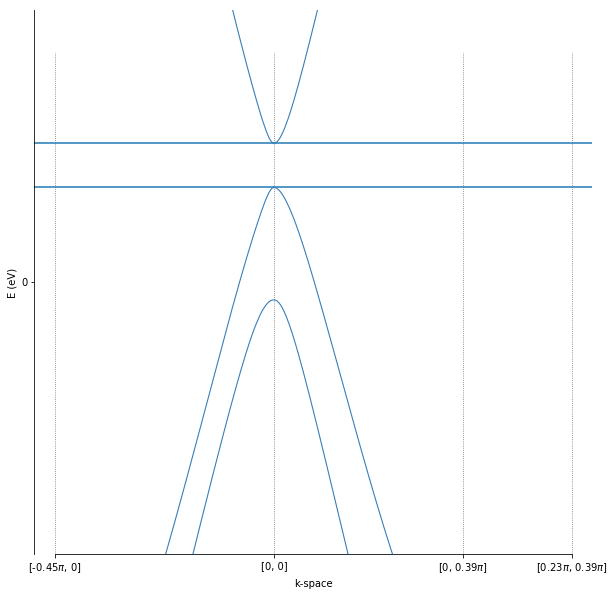

In [62]:
plt.figure(figsize=(10,10))
bands.plot()
plt.ylim(-0.2,0.2)
#plt.axhline(-0.01)
#plt.axhline(0.7)
#plt.axhline(-0.7)

solver.set_wave_vector([0, 0])
eig = solver.eigenvalues
N = len(eig)
eig0 = eig[143]
eig1 = eig[144]
plt.axhline(eig1)
plt.axhline(eig0)

print(eig0-eig1)

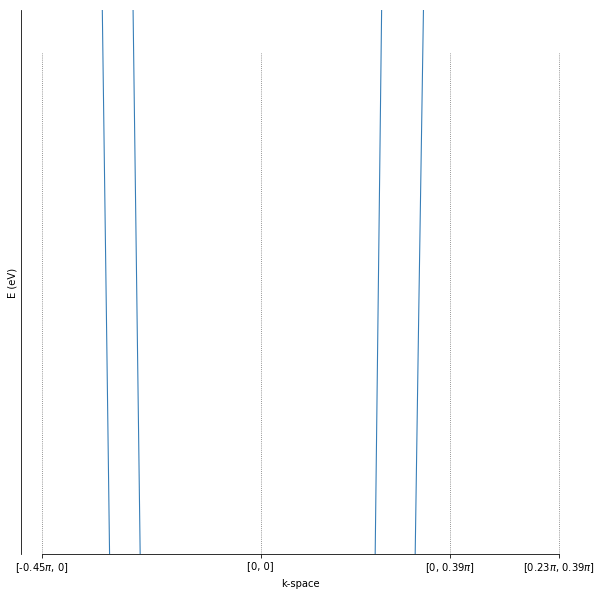

In [61]:
plt.figure(figsize=(10,10))
bands.plot()
plt.ylim(0.53,0.55)
plt.axhline(-0.01)
plt.axhline(0.7)
plt.axhline(-0.7)

## CellSize=13

0.38221306


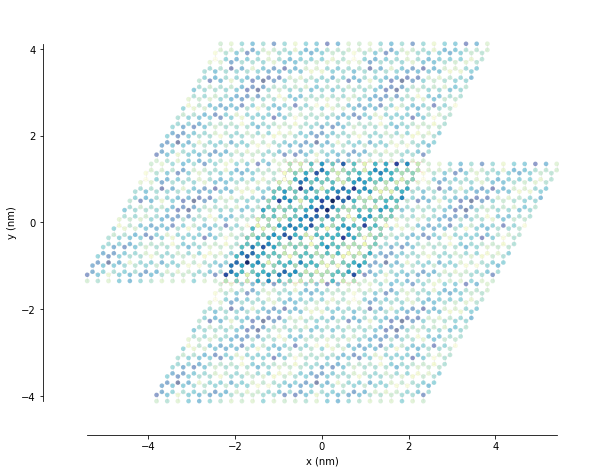

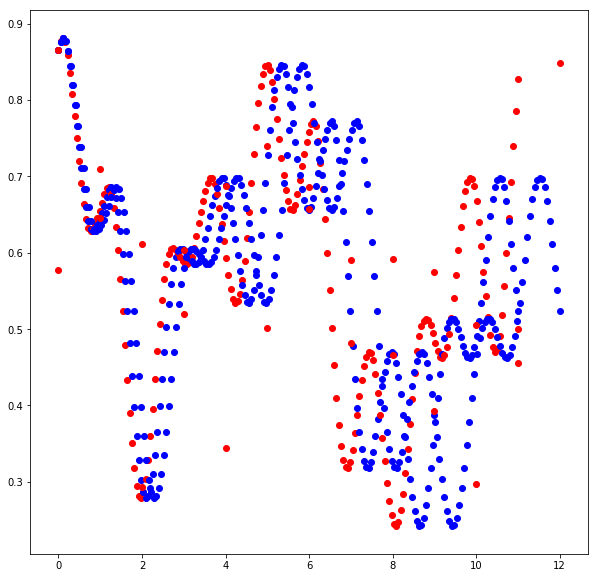

In [19]:
cellSize = 13

zdata = np.loadtxt("20790z.txt")
zdata = np.flip(zdata, 1)
zdata = zdata*1.5*10**10
f=interp2d(xdata, ydata, zdata, kind='cubic') #Using interp2d

rot=np.array([[np.cos(theta*np.pi/180),-np.sin(theta*np.pi/180)],
              [np.sin(theta*np.pi/180),np.cos(theta*np.pi/180)]])

target=[-2.2140002, -1.2072394]
target2=[0.49199986, -1.2072394]
VSe1=[1.286038-a1[0],1.599706-a1[1]]
VSe2=[4.109050-a1[0],2.258409-a1[1]]
            
a=VSe1[0]-np.dot(rot,target)[0]
b=VSe1[1]-np.dot(rot,target)[1]
def wavy(theta,a,b):
    @pb.onsite_energy_modifier
    def potential(x, y):
        xdata_temp=np.zeros(len(x))
        ydata_temp=np.zeros(len(y))
        pot=np.zeros(len(x))
        for i in range(len(x)):
            xdata_temp[i]=np.dot(rot,[x[i],y[i]])[0]+a
            ydata_temp[i]=np.dot(rot,[x[i],y[i]])[1]+b
            pot[i]=f(xdata_temp[i],ydata_temp[i])
            #plt.scatter(xdata_temp[i],ydata_temp[i], c='r')
        #print(pot[1], pot[2],pot[3])
        return pot
    return potential

model = pb.Model(
    monolayer_graphene(),
    pb.primitive(a1=cellSize, a2=cellSize),
    pb.translational_symmetry(a1=cellSize*0.246, a2=cellSize*0.246),
    wavy(theta,a,b)
)

plt.figure(figsize=(10,10))
model.onsite_map.plot(site_radius=0.04)
print(model.onsite_map.data[0])
#plt.imshow(zdata, vmin=zdata.min(), vmax=zdata.max(), origin='lower',
#           extent=[xdata.min(), xdata.max(), ydata.min(), ydata.max()])
plt.figure(figsize=(10,10))

x_ori=np.arange(VSe1[0],VSe2[0], step=dx/201)
y_ori=np.arange(VSe1[1],VSe2[1], step=dy/201)
x_red=np.arange(np.dot(rot, target)[0]+a, np.dot(rot, target2)[0]+a, step=(np.dot(rot, target2)[0]-np.dot(rot, target)[0])/201)
y_red=np.arange(np.dot(rot, target)[1]+b, np.dot(rot, target2)[1]+b, step=(np.dot(rot, target2)[1]-np.dot(rot, target)[1])/201)

for i in range(201):
    plt.scatter(i/200*11, f(x_ori[i],y_ori[i]), c='r') 
    plt.scatter(i/200*11, f(x_red[i],y_red[i]), c='b') 
plt.scatter(range(12), model.onsite_map.data[144:144+12], c='r')
                
for i in range(201):
    plt.scatter(i/200*12, f(x_red[i],y_red[i]), c='b') 

plt.scatter(range(13), model.onsite_map.data[169:169+13], c='r')

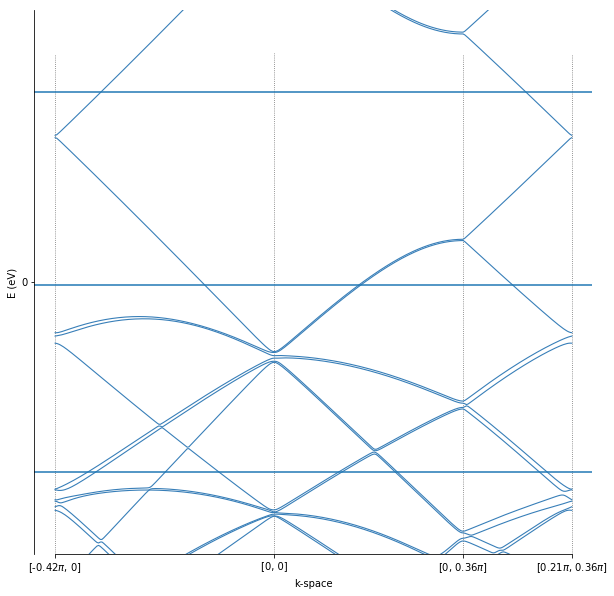

In [20]:
solver = pb.solver.lapack(model)
a_cc = graphene.a_cc
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 0]
M = [0, 2*np.pi / (3*a_cc)/cellSize]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 2*np.pi / (3*a_cc)/cellSize]
bands = solver.calc_bands(K1, Gamma, M, K2,step=0.01)
plt.figure(figsize=(10,10))
bands.plot()
plt.ylim(-1.0,1.0)
plt.axhline(-0.01)
plt.axhline(0.7)
plt.axhline(-0.7)

## mismatch

In [21]:
cellSize = 12
zdata2 = np.loadtxt("20790z.txt")
zdata2 = np.flip(zdata2, 0)
zdata2 = zdata2*(2.0*10**10)
model = pb.Model(
    monolayer_graphene(),
    pb.primitive(a1=cellSize, a2=cellSize),
    pb.translational_symmetry(a1=cellSize*0.246, a2=cellSize*0.246),
    wavy(theta+5,a,b)
)

In [22]:
solver = pb.solver.lapack(model)
a_cc = graphene.a_cc
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 0]
M = [0, 2*np.pi / (3*a_cc)/cellSize]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 2*np.pi / (3*a_cc)/cellSize]
bands = solver.calc_bands(K1, Gamma, M, K2,step=0.01)

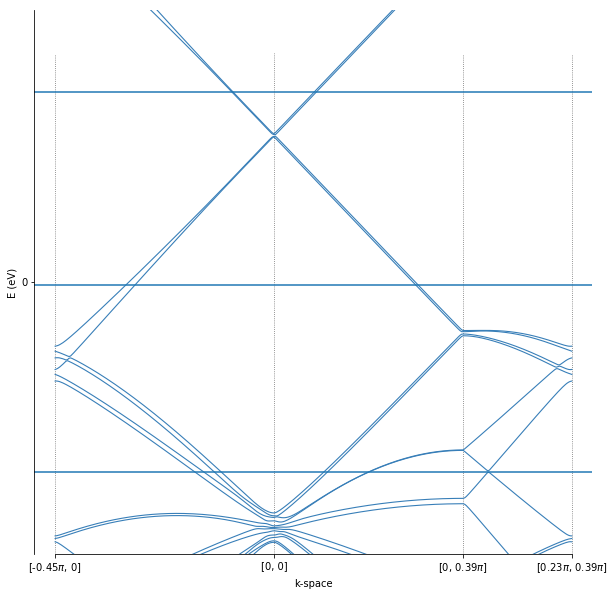

In [23]:
plt.figure(figsize=(10,10))
bands.plot()
plt.ylim(-1.0,1.0)
plt.axhline(-0.01)
plt.axhline(0.7)
plt.axhline(-0.7)

In [24]:
model = pb.Model(
    monolayer_graphene(),
    pb.primitive(a1=cellSize, a2=cellSize),
    pb.translational_symmetry(a1=cellSize*0.246, a2=cellSize*0.246),
    wavy(theta-4,a,b)
)

In [25]:
solver = pb.solver.lapack(model)
a_cc = graphene.a_cc
Gamma = [0, 0]
K1 = [-4*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 0]
M = [0, 2*np.pi / (3*a_cc)/cellSize]
K2 = [2*np.pi / (3*np.sqrt(3)*a_cc)/cellSize, 2*np.pi / (3*a_cc)/cellSize]
bands = solver.calc_bands(K1, Gamma, M, K2,step=0.01)

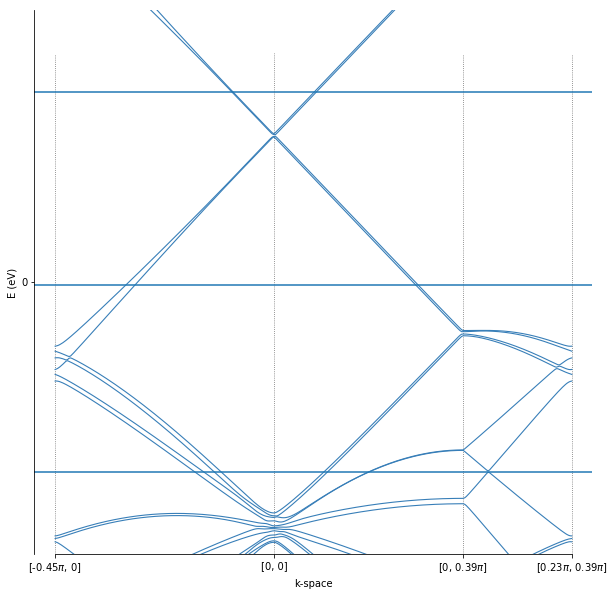

In [26]:
plt.figure(figsize=(10,10))
bands.plot()
plt.ylim(-1.0,1.0)
plt.axhline(-0.01)
plt.axhline(0.7)
plt.axhline(-0.7)